In [14]:
import os
from PIL import Image, ImageEnhance, ImageOps
import torch
import matplotlib.pyplot as plt
from diffusers import (
    StableDiffusionControlNetPipeline,
    StableDiffusionInpaintPipeline,
    ControlNetModel
)
from diffusers.utils import load_image

# Set your GPU (update if needed)
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # or "3" if you want GPU 3


In [15]:
# Your file paths and prompt
original_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/standalone_shirts/1907.jpg"
sketch_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/sketches/1907_sketch.png"
mask_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/masks/1907_mask.png"
prompt = "green fur tshirt"


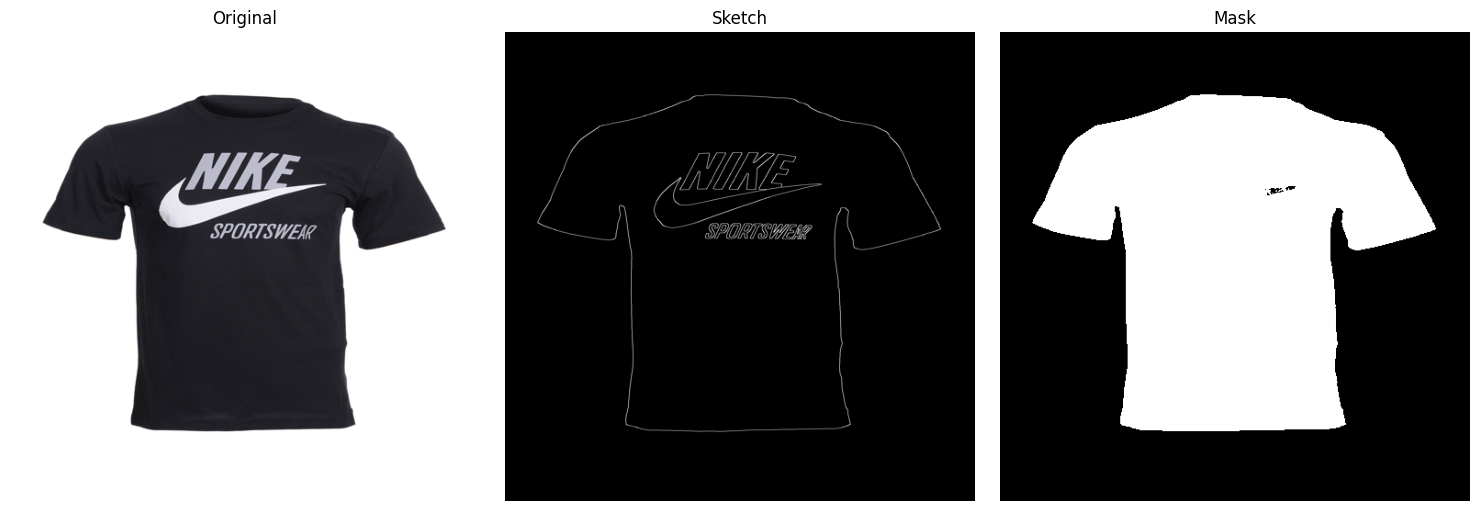

In [16]:
# Load original image
original_image = load_image(original_path).resize((512, 512)).convert("RGB")

# Load and enhance sketch
sketch_image = Image.open(sketch_path).resize((512, 512)).convert("L")
sketch_image = ImageOps.invert(sketch_image)
sketch_image = ImageEnhance.Contrast(sketch_image).enhance(2.0).convert("RGB")

# Load and binarize mask
mask_image = Image.open(mask_path).resize((512, 512)).convert("L")
mask_image = mask_image.point(lambda x: 255 if x > 128 else 0).convert("RGB")

# Visual debug
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(original_image); axs[0].set_title("Original"); axs[0].axis("off")
axs[1].imshow(sketch_image); axs[1].set_title("Sketch"); axs[1].axis("off")
axs[2].imshow(mask_image); axs[2].set_title("Mask"); axs[2].axis("off")
plt.tight_layout(); plt.show()


In [17]:
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11p_sd15_scribble",
    torch_dtype=torch.float16
).to("cuda")

controlnet_pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

controlnet_pipe.enable_attention_slicing()

with torch.inference_mode(), torch.autocast("cuda"):
    generated_shirt = controlnet_pipe(
        prompt=prompt,
        image=sketch_image,
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [18]:
inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")

inpaint_pipe.enable_attention_slicing()

with torch.inference_mode(), torch.autocast("cuda"):
    final_result = inpaint_pipe(
        prompt=prompt,
        image=original_image,
        mask_image=mask_image,
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /data/home/huixian/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /data/home/huixian/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /data/home/huixian/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /data/home/huixian/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/30 [00:00<?, ?it/s]

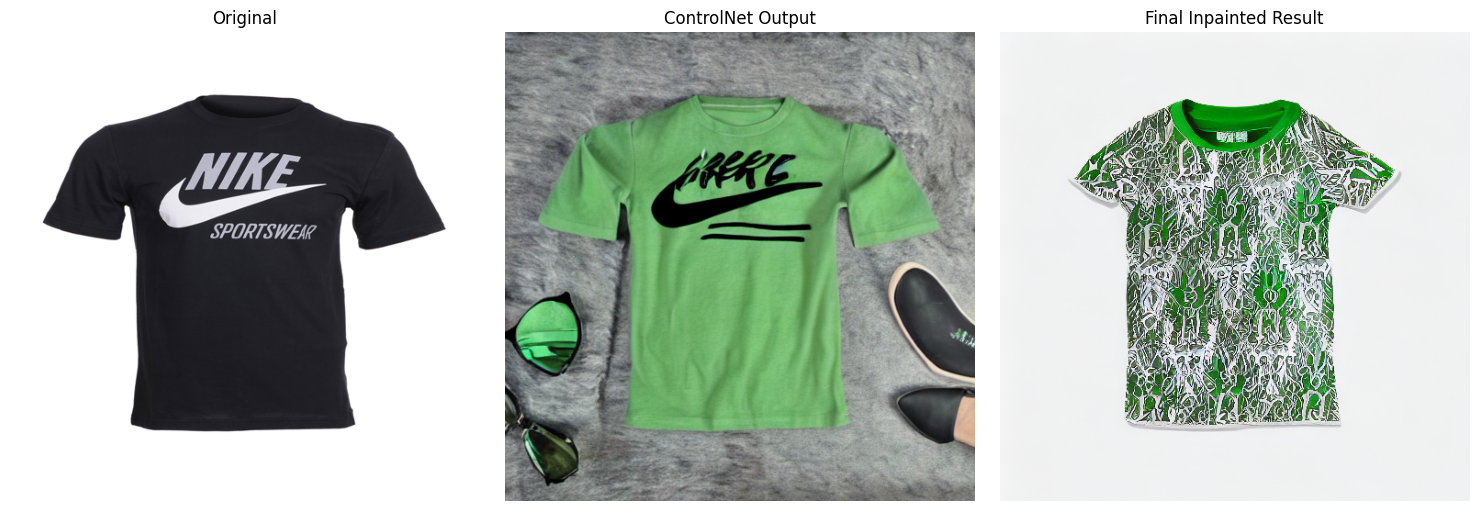

: 

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(original_image); axs[0].set_title("Original"); axs[0].axis("off")
axs[1].imshow(generated_shirt); axs[1].set_title("ControlNet Output"); axs[1].axis("off")
axs[2].imshow(final_result); axs[2].set_title("Final Inpainted Result"); axs[2].axis("off")
plt.tight_layout(); plt.show()
